# **Week 1: Intro to R and data types**
```
.------------------------------------.
|   __  ____  ______  _  ___ _____   |
|  |  \/  \ \/ / __ )/ |/ _ \___  |  |
|  | |\/| |\  /|  _ \| | | | | / /   |
|  | |  | |/  \| |_) | | |_| |/ /    |
|  |_|  |_/_/\_\____/|_|\___//_/     |
'------------------------------------'

```


# Icebreaker and warm-up activity
In groups of 2 - 4, work together to get to know each other and collect some different data from people around you.


| Prompt                                      | My answer | New friend 1 | New friend 2 | New friend 3 |      Data Type       |
|---------------------------------------------|-----------|-----------|-----------|-----------|--------------|
| Name                        |   Isaac  |    Valerie  |     Zac      |   Tanay    |  Categorical  |
| Degree                      |    BIT       |    BIT     |   BGIE   |  Business/Maths  | Categorical |
| Hours slept last night      |     8     |     8     |     6    |    10   | Continuous Ordinal |
| Travel time to uni          |     20 minutes     |    20 minutes     |      1 hour     |   30 minutes    | Continuous Ordinal |
| Programming knowledge (Low-High)                         |    mid    |     mid    |    low     |   low  | Categorical |
| Favourite drink             |     Water     |   Water    |    Water    |   Water  | Categorical |
| Animal that would win a triathalon                    |    Monkey   |     Human    |    Turtle    |   Human  |  Categorical |
| Excitement about uni (1-5)  |   4   |   4   |   4   |   4   | Discrete and Ordinal |


As a group, decide what type of data each row represents.
- Name = Categorical
- Degree Categorical
- Hours slept = continuous Ordinal
- Travel time to uni = Continuous Ordinal
- Programing Language = Categorical
- Favourite drink = Categorical
- Animal Triathalon = Categorical
- Excitement = Discrete and Ordinal

## **Pre-Configurating the Notebook**

### **Switching to the R Kernel on Colab**

By default, Google Colab uses Python as its programming language. To use R instead, you’ll need to manually switch the kernel by going to **Runtime > Change runtime type**, and selecting R as the kernel. This allows you to run R code in the Colab environment.

However, our notebook is already configured to use R by default. Unless something goes wrong, you shouldn’t need to manually change runtime type.

### **Importing Required Datasets and Packages**
**Run the following lines of code**:

In [1]:
#Do not modify

setwd("/content")

# Remove `MXB107-Notebooks` if exists,
if (dir.exists("MXB107-Notebooks")) {
  system("rm -rf MXB107-Notebooks")
}

# Fork the repository
system("git clone https://github.com/ArwenNugteren/MXB107-Notebooks")

# Change working directory to "MXB107-Notebooks"
setwd("MXB107-Notebooks")

#
invisible(source("R/preConfigurated.R"))

Loading required package: ggplot2

Loading required package: dplyr


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Loading required package: tidyr

Loading required package: stringr

Loading required package: magrittr


Attaching package: ‘magrittr’


The following object is masked from ‘package:tidyr’:

    extract


Loading required package: IRdisplay

Loading required package: png

Warning message in library(package, lib.loc = lib.loc, character.only = TRUE, logical.return = TRUE, :
“there is no package called ‘png’”
Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Loading required package: grid

Loading required package: knitr

Loading required package: jpeg

Warning message in library(package, lib.loc = lib.loc, character.only = TRUE, logical.return = TRUE, :
“there is no package called ‘jpeg’”
I

**Do not modify the following**:

In [2]:
if (!require("testthat")) install.packages("testthat"); library("testthat")

test_that("Test if all packages have been loaded", {

  expect_true(all(c("ggplot2", "tidyr", "dplyr", "stringr", "magrittr") %in% loadedNamespaces()))

})

test_that("Test if all utility functions have been loaded", {
  expect_true(exists("skewness"))
  expect_true(exists("kurtosis"))
})

Loading required package: testthat


Attaching package: ‘testthat’


The following objects are masked from ‘package:magrittr’:

    equals, is_less_than, not




Test passed with 1 success 🥇.
Test passed with 2 successes 🥳.


# R as a calculator
We can do basic arithmetic operations in R using the symbols `+`, `-`, `*` and `/`.

Try calculating the following:

In [3]:
1 + 7
4 - 5
3 * 8
9 / 2

[1] 8

[1] -1

[1] 24

[1] 4.5

## Other mathematical operations
We can also do exponents using `**` and `^`. We can also use `log()` to take the natural logarithm. In this unit, log will always be to base $e$, unless otherwise specified. Square roots use the `sqrt()` function, and trig functions are given by `sin()`, `cos()` and `tan()`. We can also express $e$ and $\pi$ by `exp(1)` and `pi`.

Try evaluating the following expressions. Are there any unexpected results?

a)  $\left( \frac32 \right)^6 + e^{4.5} - \log(9)$.

b) $\cos(\sqrt{2}) - 1$

c) $\sin(\pi)$.

In [4]:
(3/2)^6 + exp(4.5) - log(9)
cos(sqrt(2))-1
sin(pi)

[1] 99.21053

[1] -0.8440563

[1] 1.224647e-16

<details>
<summary>▶️ Click to show the solution</summary>

```r
1.5^6 + exp(4.5) - log(9)
cos(sqrt(2))-1
sin(pi) # note that the result is not exactly 0. This is numerical rounding done by the computer
```
</details>

What happens if you do mathematically forbidden operations, such as dividing by 0, or taking the square root of a negative number?

## Variables
We can assign values to a variable using `<-` (left assignment) or `=`, then re-use that variable.

Example: The "feels like" temperature, $AT$, is given by the following formula

\begin{equation}
AT = T_a + 0.33 e - 0.7 v - 4
\end{equation}
where $T_a$ is the 'dry-bulb' temperature (what you record on the thermostat) in degrees Celsius, v is the wind speed (m/s), $e$ is the water vapour pressure in (hPa), given by $e = \frac{RH}{100} \cdot 6.105 \cdot \exp\left( \frac{17.27 \cdot T_a}{237.7 + T_a} \right)$ where $RH$ is the relative humidity in %.

You can create variables with today's weather data (look up online or on your weather app) for each of these, and then evaluate the formula. See if it matches up with the "feels like" temperature for today!

In [ ]:
# create variables

# formula for e

# formula for AT

# print the result
Ta = 20
RH = 0.8
e = (RH/100)*exp((17.27*Ta)/(237.7+Ta))

AT = Ta + 0.33*e - 0.7*v - 4

<details>
<summary>▶️ Click to show the solution</summary>

```r
# the following is an example using variables from a local weather station the day I wrote this exercise
# change the variables to your values to test it

# create variables
Ta <- 22.3
v_kmh <- 20 # wind speed in km/h
v <- v_kmh*1000/(60*60) # convert to m/s
RH <- 83

# formula for e
e = RH/100 * 6.105 * exp((17.27*Ta)/(237.7 + Ta))

# formula for AT
AT = Ta + 0.33*e - 0.7*v - 4

# print the result
print(AT)
```
</details>

# Vectors
A key part of working in R is to analyse data, which we typically have in *vectors*. We can create a vector using the `c()` command, with values separated by a comma.

**Question**: In groups of 2-4 people, find out the number of kilometres each person travelled to get to uni today.

i) Create a vector with these values and assign it to a variable.

ii) Find the total distance your group travelled to uni. What is the average distance travelled per person?

iii) Convert your vector into metres.

iv) Let's suppose next week that there are major roadworks near the city, and each person needs to take a 1km detour to get to class. Create a new vector with the distances given the detour.

v) Discussion: is this data univariate or multivariate? Is it discrete, continuous, ordinal or categorical?

vi) Can you think of other examples of both a univariate and a multivariate dataset? Also come up with an example data for each of discrete, continuous, ordinal and categorical.

In [11]:
X = c(35,1.3,1.3,4)
total_distance = sum(X)

X_m = X*1000
print(X_m)

detour_X = X+1
print(detour_X)
detour_X_m = detour_X*1000
print(detour_X_m)

# Univariate and Continuous


[1] 35000  1300  1300  4000
[1] 36.0  2.3  2.3  5.0
[1] 36000  2300  2300  5000


<details>
<summary>▶️ Click to show the solution</summary>

```r
distances <- c(21, 4, 2.3, 8)
sum(distances)
sum(distances)/4
distances*1000
distances_with_detour <- distances + 1
print(distances_with_detour)
```

v) This data is univariate as we are only measuring a single variable, distance. Distance is a continuous variable, as we can measure down to an arbitrary precision.

vi) Possible examples are given below.  

Univariate: the electricity demand for your house tomorrow.

Multivariate: conducting a survey where you measure both a person's net worth and the number of coffees they drink per day.

Discrete: The number of students attending class in week 8.

Continuous: Serotonin concentration in the bloodstream half an hour after a run.

Ordinal: GPA in QUT courses, running from 1 up to 7.

Categorical: The colour of a person's clothing.

</details>

# Working with datasets
To demonstrate how to work with datasets, we are going to load a dataset from a csv file with information about the MXB107 class times. We use the command `read.csv()` to get the data into R.

In [16]:
MXB107_Info = read.csv("./datasets/MXB107_2026_S1.csv")

# check what the dataset looks like
str(MXB107_Info)
head(MXB107_Info)
tail(MXB107_Info)
glimpse(MXB107_Info)


'data.frame':	8 obs. of  9 variables:
 $ Activity      : chr  "LEC01" "LEC01" "PRC01" "PRC01" ...
 $ Day           : chr  "Wed" "Wed" "Wed" "Thu" ...
 $ Start         : int  12 12 18 8 10 10 16 8
 $ End           : int  14 14 20 10 12 12 18 10
 $ Duration      : chr  "2 hrs" "2 hrs" "2 hrs" "2 hrs" ...
 $ Location      : chr  "Gardens Point" "Online" "Gardens Point" "Gardens Point" ...
 $ Room          : chr  "GP-S-403" "-" "GP-S-519" "GP-D-416" ...
 $ Dates         : chr  "25/2-1/4, 15/4-27/5" "25/2-1/4, 15/4-27/5" "25/2-1/4, 15/4-27/5" "26/2-2/4, 16/4-28/5" ...
 $ Teaching_Staff: chr  "Chris Drovandi" "Chris Drovandi" "Nicholas Gecks-Preston" "Arwen Nugteren" ...


,Activity,Day,Start,End,Duration,Location,Room,Dates,Teaching_Staff
,<chr>,<chr>,<int>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>
1,LEC01,Wed,12,14,2 hrs,Gardens Point,GP-S-403,"25/2-1/4, 15/4-27/5",Chris Drovandi
2,LEC01,Wed,12,14,2 hrs,Online,-,"25/2-1/4, 15/4-27/5",Chris Drovandi
3,PRC01,Wed,18,20,2 hrs,Gardens Point,GP-S-519,"25/2-1/4, 15/4-27/5",Nicholas Gecks-Preston
4,PRC01,Thu,8,10,2 hrs,Gardens Point,GP-D-416,"26/2-2/4, 16/4-28/5",Arwen Nugteren
5,PRC01,Thu,10,12,2 hrs,Gardens Point,GP-G-216,"26/2-2/4, 16/4-28/5",Matt Begun
6,PRC01,Thu,10,12,2 hrs,Gardens Point,GP-D-416,"26/2-2/4, 16/4-28/5",Arwen Nugteren


,Activity,Day,Start,End,Duration,Location,Room,Dates,Teaching_Staff
,<chr>,<chr>,<int>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>
3,PRC01,Wed,18,20,2 hrs,Gardens Point,GP-S-519,"25/2-1/4, 15/4-27/5",Nicholas Gecks-Preston
4,PRC01,Thu,8,10,2 hrs,Gardens Point,GP-D-416,"26/2-2/4, 16/4-28/5",Arwen Nugteren
5,PRC01,Thu,10,12,2 hrs,Gardens Point,GP-G-216,"26/2-2/4, 16/4-28/5",Matt Begun
6,PRC01,Thu,10,12,2 hrs,Gardens Point,GP-D-416,"26/2-2/4, 16/4-28/5",Arwen Nugteren
7,PRC01,Thu,16,18,2 hrs,Online,-,"26/2-2/4, 16/4-28/5",Minh Long Nguyen
8,PRC01,Fri,8,10,2 hrs,Gardens Point,GP-G-216,"27/2-3/4, 17/4-29/5",Arwen Nugteren


Rows: 8
Columns: 9
$ Activity       <chr> "LEC01", "LEC01", "PRC01", "PRC01", "PRC01", "PRC01", "…
$ Day            <chr> "Wed", "Wed", "Wed", "Thu", "Thu", "Thu", "Thu", "Fri"
$ Start          <int> 12, 12, 18, 8, 10, 10, 16, 8
$ End            <int> 14, 14, 20, 10, 12, 12, 18, 10
$ Duration       <chr> "2 hrs", "2 hrs", "2 hrs", "2 hrs", "2 hrs", "2 hrs", "…
$ Location       <chr> "Gardens Point", "Online", "Gardens Point", "Gardens Po…
$ Room           <chr> "GP-S-403", "-", "GP-S-519", "GP-D-416", "GP-G-216", "G…
$ Dates          <chr> "25/2-1/4, 15/4-27/5", "25/2-1/4, 15/4-27/5", "25/2-1/4…
$ Teaching_Staff <chr> "Chris Drovandi", "Chris Drovandi", "Nicholas Gecks-Pre…


In [18]:
unique(MXB107_Info$Day)

[1] "Wed" "Thu" "Fri"

Firstly, we want to extract a single column of dataset using `$`. Assign the room for each class to a vector called `rooms` and get it to print out.

In [21]:
rooms = MXB107_Info$Room
print(rooms)

[1] "GP-S-403" "-"        "GP-S-519" "GP-D-416" "GP-G-216" "GP-D-416" "-"       
[8] "GP-G-216"


<details>
<summary>▶️ Click to show the solution</summary>

```r
rooms = MXB107_Info$Room
print(rooms)
```

</details>

Can we select only classes that start on Wednesday? What about classes that aren't lectures? We can use the logical commands `==` and `!=` to express equal and not equal.

In [22]:
MXB107_Info$Day == "Wed"

[1]  TRUE  TRUE  TRUE FALSE FALSE FALSE FALSE FALSE

<details>
<summary>▶️ Click to show the solution</summary>

```r
wednesday_class = MXB107_Info$Day == "Wed"
not_lectures = MXB107_Info$Activity != "LEC01"
print(wednesday_class)
print(not_lectures)

# this doesn't give us very much useful information, we want to show all the other details about the classes
subset(MXB107_Info, wednesday_class)
subset(MXB107_Info, not_lectures)
```

</details>

We can also combine conditions using the `&` symbol, and express "or" with `|`. See if you can print all classes that start after 9:00 AM on either Thursday or Friday and are not online.

In [37]:
subset(MXB107_Info, MXB107_Info$Start > 9 & (MXB107_Info$Day == "Thu" | MXB107_Info$Day == "Fri") & MXB107_Info$Location != "Online")

,Activity,Day,Start,End,Duration,Location,Room,Dates,Teaching_Staff
,<chr>,<chr>,<int>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>
5,PRC01,Thu,10,12,2 hrs,Gardens Point,GP-G-216,"26/2-2/4, 16/4-28/5",Matt Begun
6,PRC01,Thu,10,12,2 hrs,Gardens Point,GP-D-416,"26/2-2/4, 16/4-28/5",Arwen Nugteren


<details>
<summary>▶️ Click to show the solution</summary>

```r
notOnline = MXB107_Info$Location != "Online"
thu_fri = (MXB107_Info$Day == "Thu" | MXB107_Info$Day == "Fri")
startAfter9AM = MXB107_Info$Start > 9
subset(MXB107_Info, notOnline & thu_fri & startAfter9AM)
```

</details>

We also define new columns using `$`. Try creating a column called `Duration`.

In [39]:
MXB107_Info$Duration = MXB107_Info$End - MXB107_Info$Start
MXB107_Info

Activity,Day,Start,End,Duration,Location,Room,Dates,Teaching_Staff
<chr>,<chr>,<int>,<int>,<int>,<chr>,<chr>,<chr>,<chr>
LEC01,Wed,12,14,2,Gardens Point,GP-S-403,"25/2-1/4, 15/4-27/5",Chris Drovandi
LEC01,Wed,12,14,2,Online,-,"25/2-1/4, 15/4-27/5",Chris Drovandi
PRC01,Wed,18,20,2,Gardens Point,GP-S-519,"25/2-1/4, 15/4-27/5",Nicholas Gecks-Preston
PRC01,Thu,8,10,2,Gardens Point,GP-D-416,"26/2-2/4, 16/4-28/5",Arwen Nugteren
PRC01,Thu,10,12,2,Gardens Point,GP-G-216,"26/2-2/4, 16/4-28/5",Matt Begun
PRC01,Thu,10,12,2,Gardens Point,GP-D-416,"26/2-2/4, 16/4-28/5",Arwen Nugteren
PRC01,Thu,16,18,2,Online,-,"26/2-2/4, 16/4-28/5",Minh Long Nguyen
PRC01,Fri,8,10,2,Gardens Point,GP-G-216,"27/2-3/4, 17/4-29/5",Arwen Nugteren


<details>
<summary>▶️ Click to show the solution</summary>

```r
MXB107_Info$Duration = MXB107_Info$End - MXB107_Info$Start
str(MXB107_Info)
```

</details>

**Question**: can you find the average (mean) class duration? What about the average start time? Is this a useful value?

In [40]:
mean(MXB107_Info$Duration)

[1] 2

<details>
<summary>▶️ Click to show the solution</summary>

```r
mean(MXB107_Info$Duration)
mean(MXB107_Info$Start)
```

</details>

#### **Exercise**

How many classes are held online vs in-person for each type (Lecture, Practical)?

In [52]:
online = MXB107_Info$Location == "Online"
in_person = MXB107_Info$Location != "Online"
lec = MXB107_Info$Activity == "LEC01"
prac = MXB107_Info$Activity == "PRC01"

sum(online & lec)
sum(online & prac)
sum(in_person & prac)
sum(in_person & lec)

[1] 1

[1] 1

[1] 5

[1] 1

<details>
<summary>▶️ Click to show the solution</summary>

```r
online_prac = MXB107_Info$Location == "Online" & MXB107_Info$Activity == "PRC01"
in_person_prac = MXB107_Info$Location != "Online" & MXB107_Info$Activity == "PRC01"

online_lec = MXB107_Info$Location == "Online" & MXB107_Info$Activity == "LEC01"
in_person_lec = MXB107_Info$Location != "Online" & MXB107_Info$Activity == "LEC01"

# note that sum will add up all the TRUE values
sum(online_prac)
sum(in_person_prac)
sum(online_lec)
sum(in_person_lec)
```

</details>

# Plotting data
An important part of visualising statistical data and results is by creating plots.

## Categorical data

Let's collect data as a class on what type of pets everyone has and plot a bar chart with the numbers of each pet.

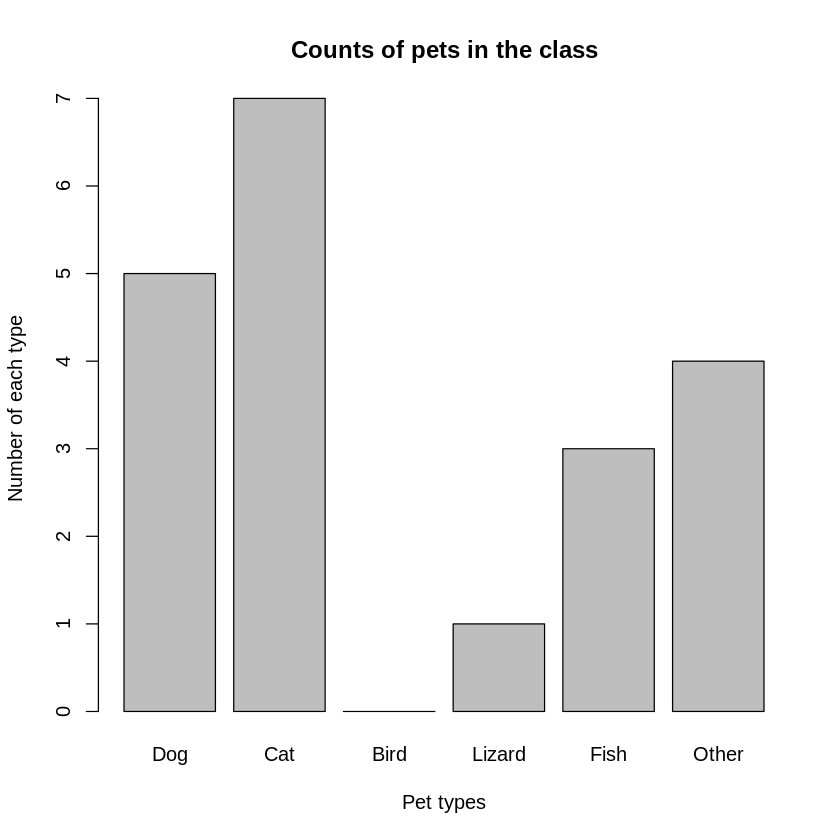

In [61]:
# types of pets
pet_types <- c("Dog", "Cat", "Bird", "Lizard", "Fish", "Other")

# put in the counts in the same order
pet_counts <- c(5, 7, 0, 1, 3, 4)

# combine the names with the counts into a data frame
pet_data <- data.frame(
  pets = pet_types,
  count = pet_counts
)

# plot the pet data in a bar chart
# add in titles and labels
barplot(pet_data$count, names.arg = pet_data$pets,
        main = "Counts of pets in the class",
        xlab = "Pet types",
        ylab = "Number of each type")


<details>
<summary>▶️ Click to show the solution</summary>

```r
# types of pets (we can edit this)
pet_types <- c("Dog", "Cat", "Bird", "Lizard", "Fish", "Other")

# put in the counts in the same order
pet_counts <- c(5, 7, 0, 1, 3, 4)

# combine the names with the counts into a data frame
pet_data <- data.frame(
  pets = pet_types,
  count = pet_counts
)

# plot with a title and axis labels
barplot(pet_data$count, names.arg = pet_data$pets,
        main = "Counts of pets in the class",
        xlab = "Pet types",
        ylab = "Number of each type")
```

</details>

## Quantitative variables

**Example 1**: Let's say we want to measure the trend in the percentage of previous year 12 students beginning university each year from 2018 to 2023 to see if there are any trends (This data is from the [Australian Government Department of Education](https://www.education.gov.au/higher-education-statistics/student-data/selected-higher-education-statistics-2023-student-data/key-findings-2023-student-data)). What sort of plot would be appropriate for this? The data is given below, try plotting it and describing any trends and possible reasons for them in the data.

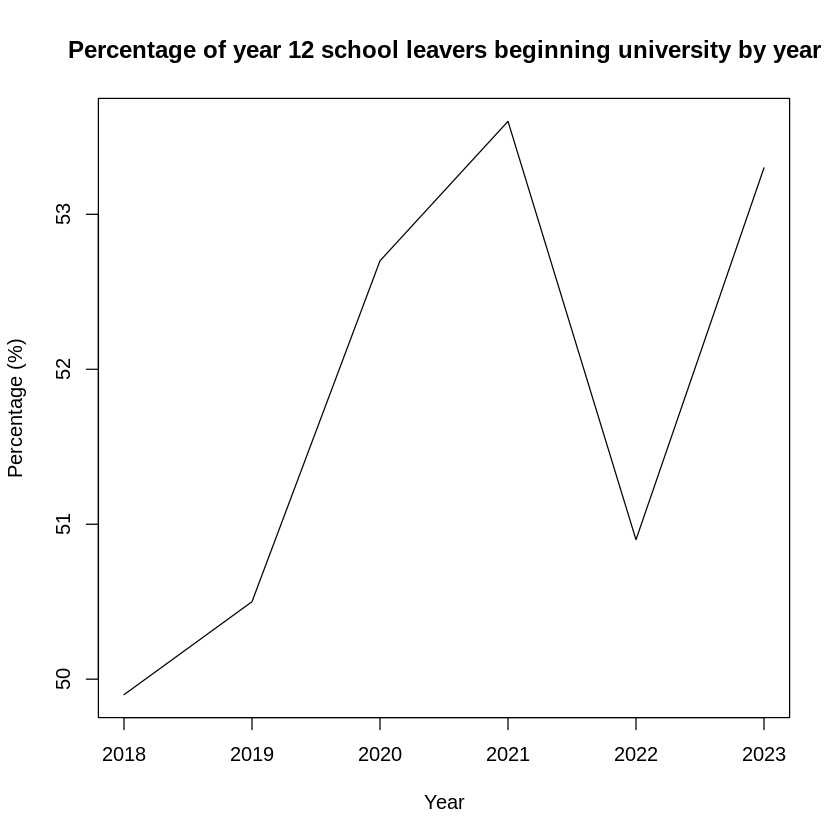

In [75]:
uni_percentage <- c(49.9, 50.5, 52.7, 53.6, 50.9, 53.3)
year <- 2018:2023

uni_data <- data.frame(
  year = year,
  percentage = uni_percentage
)

# your code to generate a plot here
plot(uni_data$year, uni_data$percentage, type="l",
     main = "Percentage of year 12 school leavers beginning university by year",
    xlab = "Year",
    ylab = "Percentage (%)")

<details>
<summary>▶️ Click to show the solution</summary>

```r
uni_percentage <- c(49.9, 50.5, 52.7, 53.6, 50.9, 53.3)
year <- 2018:2023

uni_data <- data.frame(
  year = year,
  percentage = uni_percentage
)
uni_data

plot(year, uni_percentage, type="l",
    main = "Percentage of year 12 school leavers beginning university by year",
    xlab = "Year",
    ylab = "Percentage (%)")

# we can see that there initially appears to be an increasing trend in the number of recent year 12 leavers starting university
# there is a strong peak in 2020 and 2021, with a big drop after
# one possible reason for this is that less students took a gap year during 2020 and 2021 (due to the pandemic) and started university immediately after leaving school
```

</details>

**Example 2**: The dataset `airquality` is a built in dataset for different daily measures of air quality in New York in 1973. Decide on a suitable plot for the daily temperature, then plot the results in degrees Celsius.

'data.frame':	153 obs. of  6 variables:
 $ Ozone  : int  41 36 12 18 NA 28 23 19 8 NA ...
 $ Solar.R: int  190 118 149 313 NA NA 299 99 19 194 ...
 $ Wind   : num  7.4 8 12.6 11.5 14.3 14.9 8.6 13.8 20.1 8.6 ...
 $ Temp   : int  67 72 74 62 56 66 65 59 61 69 ...
 $ Month  : int  5 5 5 5 5 5 5 5 5 5 ...
 $ Day    : int  1 2 3 4 5 6 7 8 9 10 ...


,Ozone,Solar.R,Wind,Temp,Month,Day
,<int>,<int>,<dbl>,<int>,<int>,<int>
1,41,190,7.4,67,5,1
2,36,118,8.0,72,5,2
3,12,149,12.6,74,5,3
4,18,313,11.5,62,5,4
5,NA,NA,14.3,56,5,5
6,28,NA,14.9,66,5,6


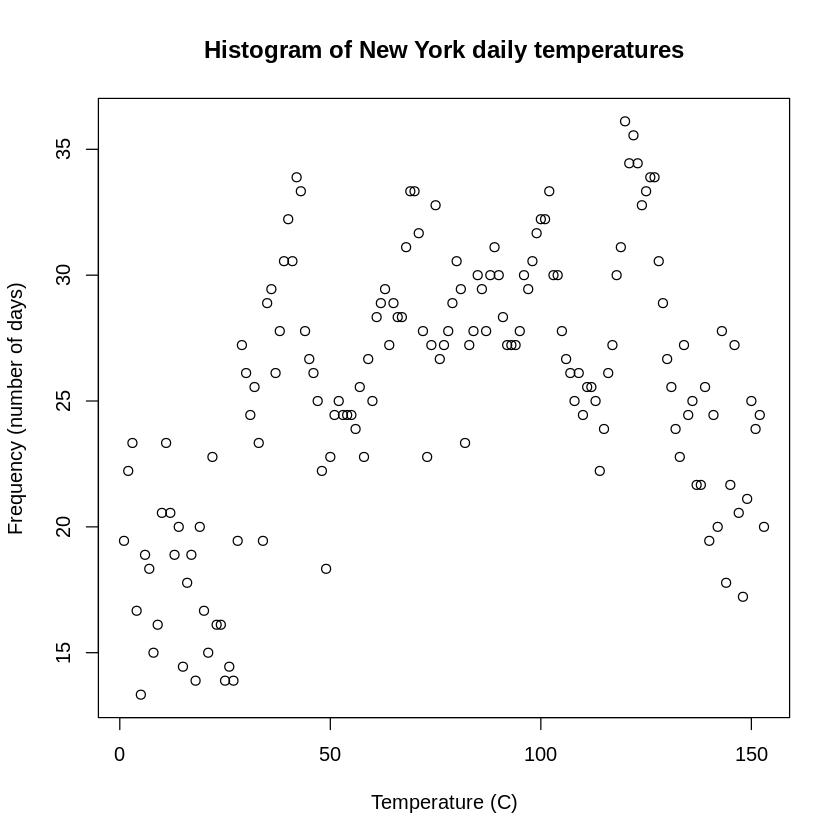

In [78]:
air_quality <- airquality

# check the type of data
str(air_quality)

head(air_quality)

plot((air_quality$Temp-32)*5/9, main = "Histogram of New York daily temperatures",
     xlab = "Temperature (C)",
     ylab = "Frequency (number of days)")



<details>
<summary>▶️ Click to show the solution</summary>

```r
air_quality <- airquality

# check the type of data
str(air_quality)

# convert to celsius
air_quality$Celsius <- (air_quality$Temp - 32) * 5/9

# plot a histogram
hist(air_quality$Celsius, main = "Histogram of New York daily temperatures",
     xlab = "Temperature (C)",
     ylab = "Frequency (number of days)")
```

</details>

**Example 3**: Now we are interested in a relationship between the temperature and the ozone level in the New York city air quality data. How should we visualise this? Is there any relationship?  

<details>
<summary>▶️ Click to show the solution</summary>

```r
plot(air_quality$Celsius, air_quality$Ozone,
     main = "Scatter plot of Ozone levels against Daily temperature",
     xlab = "Temperature (C)",
     ylab = "Ozone (ppb)")

# there appears to be a positive correlation between the variables
```

</details>

# Workshop Questions

### **EPA Fuel Economy Dataset**

A dataset containing information on over 13,500 cars sold in the US from 2010 to 2020, including measurements and characteristics related to vehicle fuel economy and specifications. Data sourced from the [US Fuel Economy website](https://www.fueleconomy.gov/feg/download.shtml).

| Variable | Description                                    |
|----------|------------------------------------------------|
| `city`   | EPA measured fuel economy in miles per gallon (city driving) |
| `hwy`    | EPA measured fuel economy in miles per gallon (highway driving) |
| `cyl`    | Number of cylinders in the engine              |
| `disp`   | Engine displacement (litres)                    |
| `drive`  | Vehicle drivetrain layout (e.g., FWD, RWD, AWD) |
| `make`   | Vehicle manufacturer name                       |
| `model`  | Vehicle model name                              |
| `trans`  | Transmission type (manual or automatic)        |
| `year`   | Vehicle model year                              |


In [79]:
epa_data = read.csv("./datasets/epa_data.csv")
str(epa_data)

'data.frame':	13569 obs. of  9 variables:
 $ city : int  16 15 16 19 19 19 19 19 19 19 ...
 $ hwy  : int  24 22 22 27 29 24 26 27 29 24 ...
 $ cyl  : int  8 8 8 4 4 4 4 4 4 4 ...
 $ disp : num  5 5 5 2 2 2.4 2.4 2 2 2.4 ...
 $ drive: chr  "Rear-Wheel Drive" "Rear-Wheel Drive" "Rear-Wheel Drive" "Rear-Wheel Drive" ...
 $ make : chr  "Jaguar" "Jaguar" "Jaguar" "Pontiac" ...
 $ model: chr  "XK" "XK" "XK Convertible" "Solstice" ...
 $ trans: chr  "Automatic" "Automatic" "Automatic" "Automatic" ...
 $ year : int  2010 2010 2010 2010 2010 2010 2010 2010 2010 2010 ...


### **Question 1**


Suppose you want to compare the distribution of the combined fuel economy between city and highway driving using the EPA dataset.

- Is the data discrete or continuous?
- What type of graphical summary would best display this comparison?
- Plot this using R.


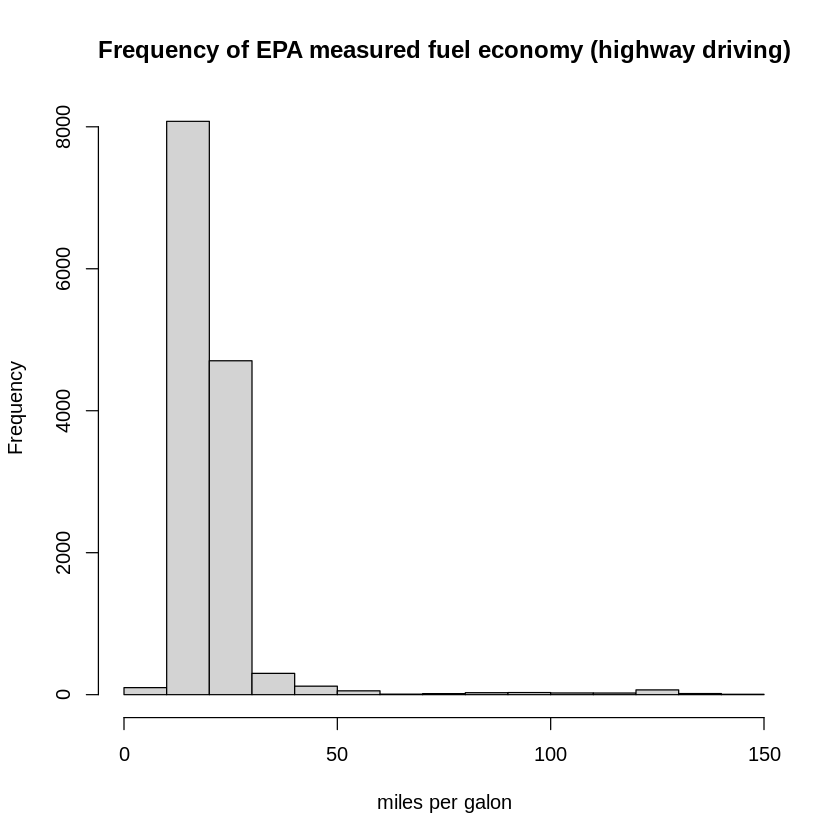

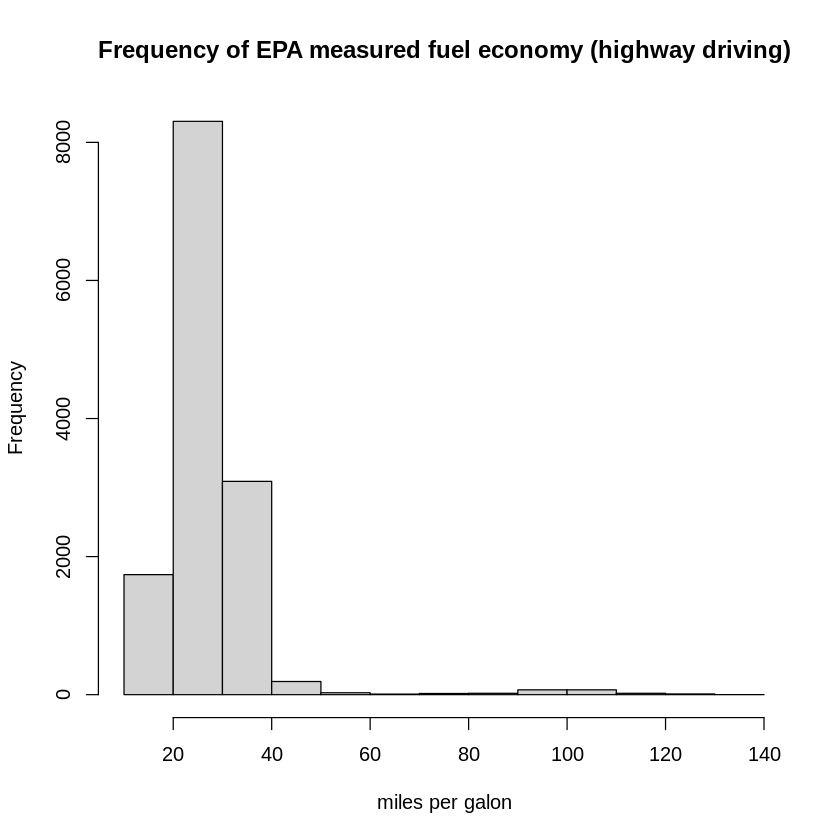

In [100]:
# Discrete
# Histogram
hist(epa_data$city, main = "Frequency of EPA measured fuel economy (highway driving)", xlab="miles per galon")
hist(epa_data$hwy, main = "Frequency of EPA measured fuel economy (highway driving)", xlab="miles per galon")

<details>
<summary>▶️ Click to show the solution </summary>

Solutions will be released at the end of the week!

</details>

### **Question 2**

Suppose you want to compare the fuel economy in city driving between manual and automatic transmissions using the EPA dataset.
- What type of graphical summary would best display this comparison?
- Plot this using R.
- Are there any trends or patterns that differ between manual and automatic transmission?

Hint: you may want to create subsets of the data to plot.

In [102]:
manual = subset(epa_data, epa_data$trans == "Automatic")
barplot(manual., manual.year)

ERROR: Error in barplot.default(manual): 'height' must be a vector or a matrix


<details>
<summary>▶️ Click to show the solution </summary>

Solutions will be released at the end of the week!

</details>

### **Question 3**

Suppose that you want to explore how engine displacement changed over time.

- What type of graph or chart would you use and why?
- Use R to plot this.
- What trends can you see?

Hint: we can use the `tapply()` function on two vectors, one specifying the data (engine displacement), and the second specifying the group (years), followed by the operation we want to do in each group (mean).

<details>
<summary>▶️ Click to show the solution </summary>

Solutions will be released at the end of the week!

</details>

### **Question 4**

Suppose you want to identify which manufacturers produced the most fuel-efficient cars given city driving EPA in the `epa_data` dataset.

- Use `tapply()` to summarise `EPA` by manufacturer. Put this in a data frame. Sort the data using `arrange()`, which takes in a data frame and a vector of what you want to sort by.

<details>
<summary>▶️ Click to show the solution </summary>

Solutions will be released at the end of the week!

</details>

- Use R to create an ordered bar chart to support your analysis. Is this plot easy to interpret?

<details>
<summary>▶️ Click to show the solution </summary>

Solutions will be released at the end of the week!

</details>

- How might you improve the previous plot to better answer the question of which are the most fuel efficient manufacturers?

<details>
<summary>▶️ Click to show the solution </summary>

Solutions will be released at the end of the week!

</details>

# **Optional: Data Visualisation via `ggplot2'**

*The following is extension material on a commonly used plotting library for R. While it offers more functionality and customisability, it is also more complicated to learn to use. You do not need to use anything more than base R plotting functions during this course, but you are welcome to explore the exercises below if you are interested in learning how to use it.*

`ggplot2` is a powerful and widely-used R package for data visualisation based on the "Grammar of Graphics" concept. It allows you to create complex and elegant plots by layering components step-by-step.

Key features of `ggplot2`:

- **Layered approach**: Build plots by adding layers like stacking LEGO blocks.
- **Consistent syntax**: Uses a clear, declarative style making plots easy to read and modify.
- **Highly customisable**: Control every detail of your plot’s appearance.
- **Works well with "tidy" data**: Designed to work seamlessly with data in long format.

### **Basic Data Visualisation Principles**

Depending on how we create graphical depictions of data, we can alter the viewer’s impression of the data; in other words, if a picture is worth a thousand words, then how we make the picture can change the story. Ideally, we want our graphical summaries to be as objective as possible; we want the data to speak for themselves. There are no hard and fast rules for creating graphical summaries. Still, there are some basic principles to follow:

- Always have a title for your graphical summary.
- Titles should accurately describe the variables and the relationship shown in the summary. If one of the axes is time or the data are for a specific period, that should be in the title.
- Clearly label the axes and include units.
When comparing two data sets, the axes for each summary should match.


### **`iris` dataset**

To demonstrate the use of `ggplot2`, we will use a new dataset named `iris`, a classic dataset containing measurements of `Sepal.Length`, `Sepal.Width`, `Petal.Length`, and `Petal.Width` for three `Species` of iris flowers.

In [ ]:
iris = read.csv("./datasets/iris.csv")
head(iris) # head shows the first few rows of a dataset

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
1,5.1,3.5,1.4,0.2,setosa
2,4.9,3.0,1.4,0.2,setosa
3,4.7,3.2,1.3,0.2,setosa
4,4.6,3.1,1.5,0.2,setosa
5,5.0,3.6,1.4,0.2,setosa
6,5.4,3.9,1.7,0.4,setosa


### **Stacking LEGO Blocks**

Think of building a plot in `ggplot2` like stacking LEGO blocks, where each block adds something new.


#### **First LEGO Block: Data**
We tell ggplot what data to use.

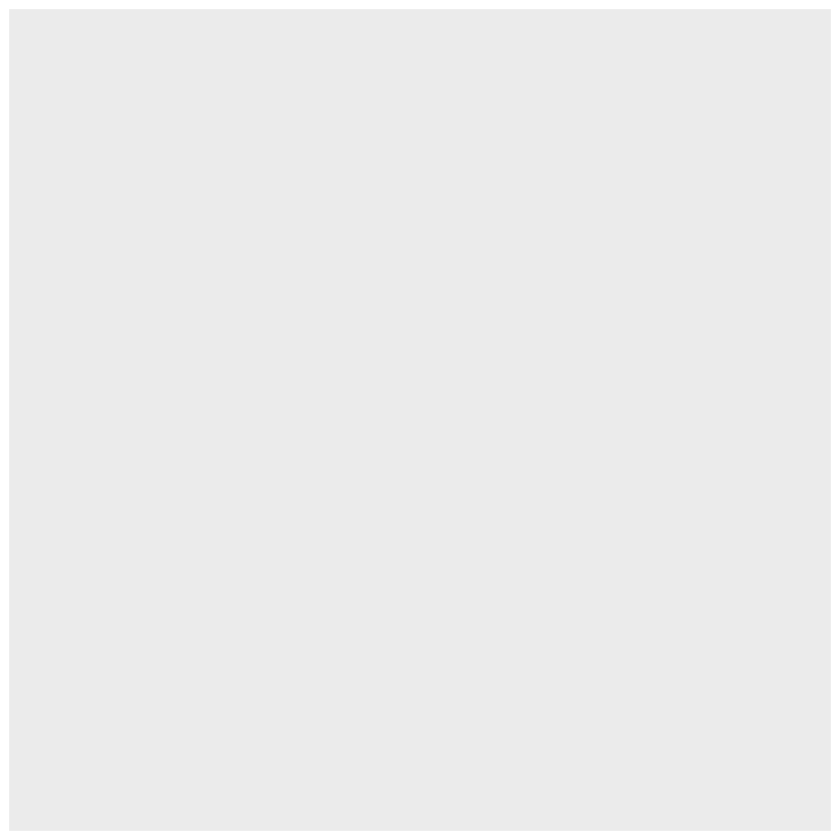

In [ ]:
ggplot(data = iris)

#### **Second LEGO Block: Aesthetics**

The aesthetics block `aes()` is like setting up the grid and rules of your LEGO baseplate — it defines how data variables map to visual properties on the plot.

For example:
- `x = Sepal.Width` defines what data goes along the horizontal axis (x-axis).
- `y = Petal.Length` defines what data goes along the vertical axis (y-axis).
- `color = Species` decides how points are colored based on their group.

Yes, `ggplot2` natively understand column names. In fact, `ggplot2` and `dplyr` belong to a bigger family called `tidyverse`.

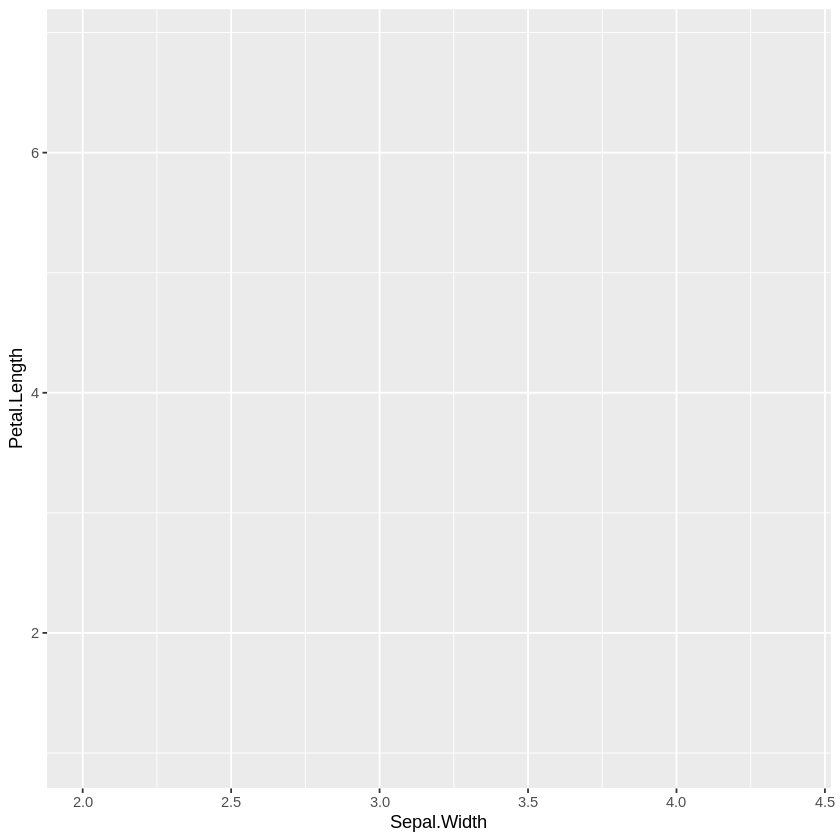

In [ ]:
ggplot(data = iris, aes(x = Sepal.Width, y = Petal.Length, color = Species))

#### **Third LEGO Block: The Actual Plot**

The third block defines the type of plot or visual representation you want — this is called a `geom` (geometric object). It tells `ggplot2` how to draw your data on the axes set up by the aesthetics.

Examples of `geom` include:
- `geom_point()` for scatter-plots
- `geom_line()` for line plots
- `geom_bar()` for bar charts
- `geom_histogram()` for histograms
and many more

Without adding a geom, your plot has no visual marks — just empty axes.

From now, we use the `+` operator in `ggplot2` to add layers onto our plot one by one.

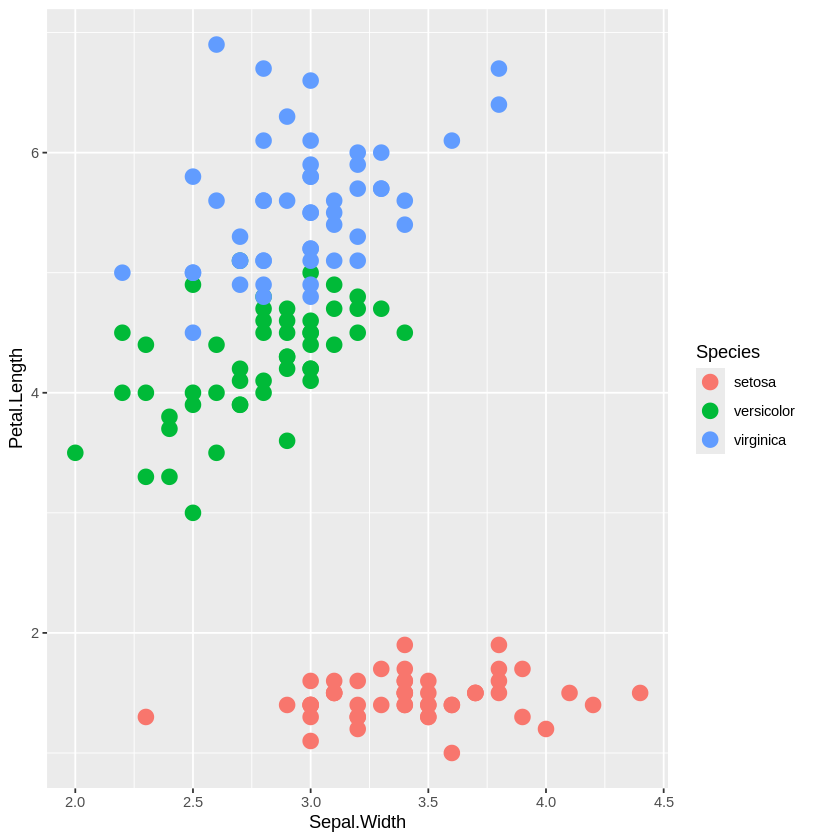

In [ ]:
ggplot(data = iris, aes(x = Sepal.Width, y = Petal.Length, color = Species)) +
geom_point(size = 4)

#### **Fourth LEGO Block: Customisation**

The fourth block in `ggplot2` is all about customizing the appearance and style of your plot.

This includes things like:

- Adding titles, axis labels, and captions using `labs()`
- Changing the theme (background, grid lines, fonts) with functions like `theme_minimal()`, `theme_classic()`, or customising with `theme()`
- Adjusting scales for axes, colors, and sizes (e.g., `scale_color_manual()`, `scale_x_continuous()`)
- Adding facets to create small multiples (`facet_wrap()`, `facet_grid()`)

This block is like painting and decorating your LEGO model — after you’ve built the structure, you choose colors, textures, and details to make it look exactly how you want.

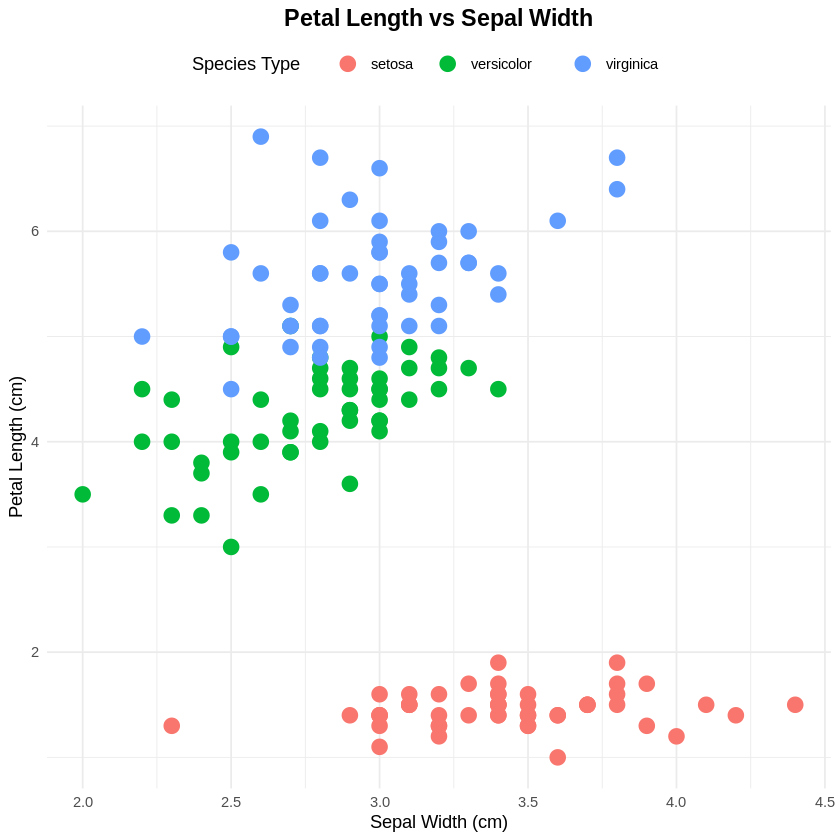

In [ ]:
ggplot(data = iris, aes(x = Sepal.Width, y = Petal.Length, color = Species)) +
  geom_point(size = 4) +
  labs(
    title = "Petal Length vs Sepal Width",
    x = "Sepal Width (cm)",
    y = "Petal Length (cm)",
    color = "Species Type"
  ) +
  theme_minimal() +
  theme(
    plot.title = element_text(face = "bold", size = 14, hjust = 0.5),
    legend.position = "top"
  )


#### **Exercise**

Create a scatter plot of `Sepal.Length` vs `Sepal.Width`, colored by `Species`. Follow the same block-based `ggplot2` structure we discussed.


<details>
<summary>▶️ Click to show the solution</summary>

```r
ggplot(data = iris, aes(x = Sepal.Width, y = Sepal.Length, color = Species)) +
  geom_point(size = 4) +
  labs(
    title = "Sepal Length vs Sepal Width",
    x = "Sepal Width (cm)",
    y = "Sepal Length (cm)",
    color = "Species Type"
  ) +
  theme_minimal() +
  theme(
    plot.title = element_text(face = "bold", size = 14, hjust = 0.5),
    legend.position = "top"
  )
```

</details>

### **Visualising Subgroups with `facet_wrap()`**

Assume that you want to create a scatter plot of `Petal.Length` vs `Sepal.Width`, however, for each species separately.

One approach is to split the dataset by `Species`, extract the `Petal.Length` and `Sepal.Width` columns for each group, create a separate scatter plot for each, and then combine or "stack" the plots to compare across species. This is not convenient.

`facet_wrap()` simplifies the process.

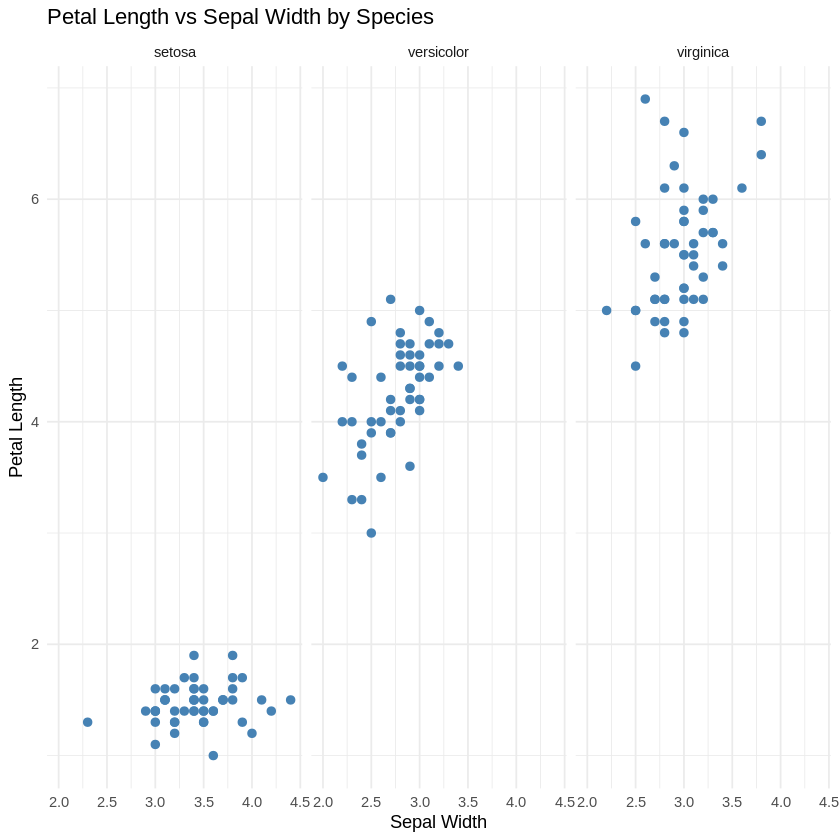

In [ ]:
ggplot(data=iris, aes(x = Sepal.Width, y = Petal.Length)) +
  geom_point(color = "steelblue", size = 2) +
  facet_wrap(~ Species) +
  theme_minimal() +
  labs(
    title = "Petal Length vs Sepal Width by Species",
    x = "Sepal Width",
    y = "Petal Length"
  )

## Exercise
Repeat the workshop exercises from above on the EPA data with `ggplot2`.